In [3]:
# %% [markdown]
# ## 케인즈의 유동성 선호 이론(화폐 시장 균형) 시뮬레이션

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider


Money Market. 실질잔고의 공급, 실질잔고에 대한 수요
\begin{align}
(M/P)^s & = { M_0 \over P_0 } \\
(M/P)^d & = l_1 \times Y_0 - l_2 \times r 
\end{align}


In [4]:

# 1. 고정 경제 파라미터 설정
P = 1.0            # 단기 고정 물가 수준
l1 = 0.50          # 화폐수요의 소득 민감도
l2 = 1500          # 화폐수요의 이자율 민감도

M = 600            # 정책변수. 이 값이 달라지면 균형은?
Y = 2000

# Y축 (이자율 r의 범위 설정)
r_vals = np.linspace(0.01, 0.40, 100)


In [5]:

def simulate_liquidity_preference(M, Y):
    """
    M: 명목 통화량 (중앙은행의 통화정책 변수)
    Y: 국민소득 (소득 변화에 따른 화폐수요 시프트)
    """
    # 실질 화폐 공급 (수직선이므로 X축 값 고정)
    MS_real = M / P
    
    # 실질 화폐 수요 공식 (r에 따라 변하는 화폐수요량 M^d 계산)
    # M^d = l1 * Y - l2 * r
    MD_real = l1 * Y - l2 * r_vals
    
    # 화폐 시장의 균형 이자율(r_eq) 계산 (M/P = l1*Y - l2*r)
    # r = (l1*Y - M/P) / l2
    r_eq = (l1 * Y - MS_real) / l2
    
    # 그래프 그리기
    plt.figure(figsize=(9, 6.5))
    
    # 화폐 공급 곡선 (수직선)
    plt.axvline(MS_real, label=f'Money Supply (M/P = {MS_real:.0f})', color='orange', linewidth=2.5)
    
    # 화폐 수요 곡선 (우하향)
    plt.plot(MD_real, r_vals, label=f'Money Demand L(Y, r)', color='#1f77b4', linewidth=2.5)
    
    # 균형점 표시
    if 0.01 <= r_eq <= 0.40:
        plt.scatter(MS_real, r_eq, color='red', s=120, zorder=5, 
                    label=f'Equilibrium Interest Rate (r* = {r_eq*100:.1f}%)')
        plt.axhline(r_eq, color='red', linestyle=':', alpha=0.5)
    
    # 그래프 스타일링
    plt.title('Theory of Liquidity Preference (Money Market)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Real Money Balances (M/P)', fontsize=12)
    plt.ylabel('Interest Rate (r)', fontsize=12)
    
    # 축 범위 고정
    plt.xlim(200, 1000)
    plt.ylim(0.00, 0.42)
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.legend(loc='upper right', fontsize=11)
    plt.show()


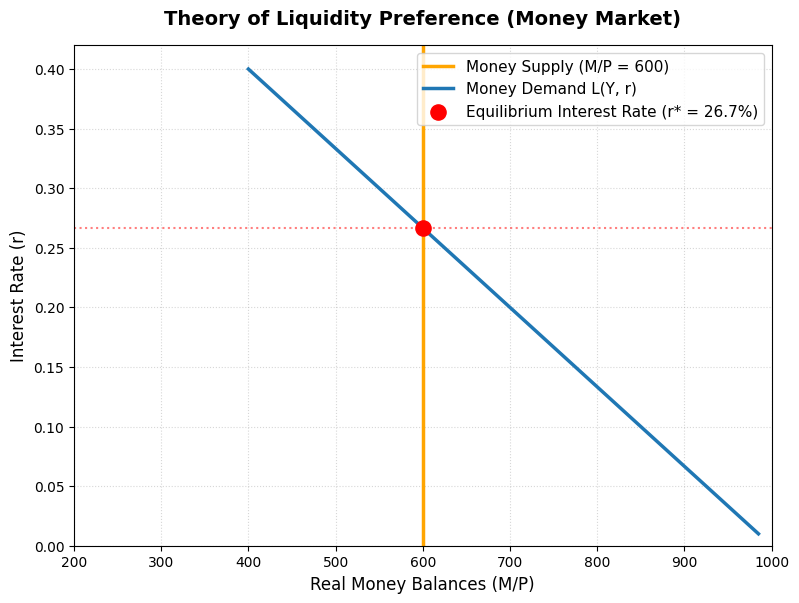

In [6]:

# M의 크기, Y 크기 변경 실험. 
simulate_liquidity_preference(M, Y)